# Predective Maintenance




### Importing dataset into a Pandas dataframe

In [ ]:
import pandas as pd
df = pd.read_csv("C:/Users/yhamz/OneDrive/Desktop/Mohamed's work/Predictive Maintainance Project/data/raw/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Basic Exploratory data analysis

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['Product ID'].duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

### Features/Target details
| Column | Meaning | Type | Unit |
|---|---|---|---|
| UDI | Unique Identifier | ID |  |
| Product ID | Consisting of quality(L,M,H) and a serial number | Categorial | |
| Type | Quality index(L,M,H) | Categorial | |
| Air temperature | Ambient temperature around the machine | Continuous | K |
| Process temperature | Internal temperature in the machine | Continuous | K |
| Rotational Speed | Machine shaft rotaional speed | Continuous | rpm |
| Torque | Rotational force applied to the tool | Continuous | Nm |
| Tool wear | Accumulated tool usage time | Continuous | min |
| Machine failure | Overall machine failure status (Target) | Binary |  |
| TWF | Tool Wear failure | Binary |  |
| HDF | Heat desipation failure | Binary |  |
| PWF | Power failure | Binary |  |
| OSF | Overstrain failure | Binary |  |
| RNF | Random failure (unpredictable event) | Binary |  |


In [7]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

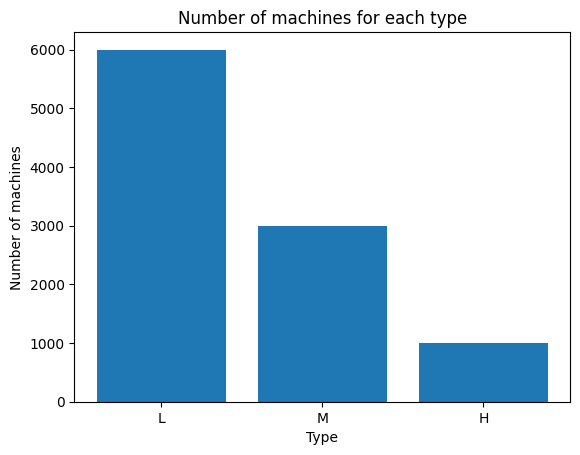

In [8]:
import matplotlib.pyplot as plt

counts = df['Type'].value_counts()

plt.bar(counts.index,counts.values)
plt.xlabel('Type')
plt.ylabel('Number of machines')
plt.title('Number of machines for each type')
plt.show()


In [9]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

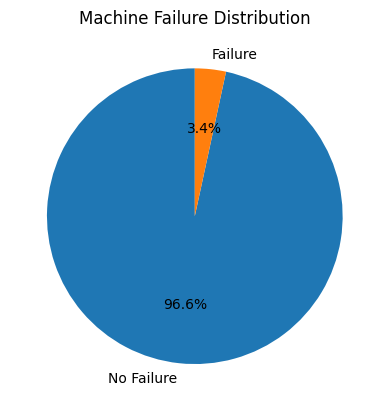

In [10]:
failure_count = df['Machine failure'].value_counts() / df['Machine failure'].count() * 100
plt.pie(
    failure_count.values,
    labels=['No Failure','Failure'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Machine Failure Distribution")
plt.show()

In [11]:
failure_cols = ['TWF','HDF','PWF','OSF','RNF']

df[failure_cols].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

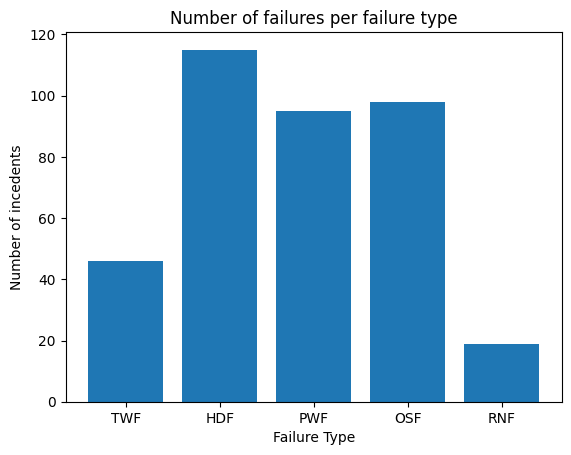

In [12]:
plt.bar(df[failure_cols].sum().index,df[failure_cols].sum().values)
plt.xlabel("Failure Type")
plt.ylabel("Number of incedents")
plt.title("Number of failures per failure type")
plt.show()

In [13]:
derived_failure = (df[failure_cols].sum(axis = 1) > 0).astype(int)
(derived_failure == df['Machine failure']).all()
# If it returns true then Machine failure = TWF OR HDF OR PWF OR OSF OR RNF
# if it returns False then there is inconsistency in failures in some rows

np.False_

In [14]:
mismatches = df.loc[derived_failure != df['Machine failure'],['Machine failure'] + failure_cols]
mismatches

,Machine failure,TWF,HDF,PWF,OSF,RNF
1221,0,0,0,0,0,1
1302,0,0,0,0,0,1
1437,1,0,0,0,0,0
1748,0,0,0,0,0,1
2072,0,0,0,0,0,1
2559,0,0,0,0,0,1
2749,1,0,0,0,0,0
3065,0,0,0,0,0,1
3452,0,0,0,0,0,1
4044,1,0,0,0,0,0


A consistency check was performed to verify whether the binary target
'Machine failure' is equal to the logical OR of the five failure-mode labels.

The dataset documentation states that Machine failure should be 1 if at least
one failure mode is active. However, a small inconsistency was observed,
mainly related to RNF / random failures.

Since RNF represents random failures independent of process parameters, and
because the failure-type columns are target-level information, these columns
will not be used as input features for the binary classification model.
They will only be used for EDA and target validation.

### Input Features Analysis

#### Air Temperature

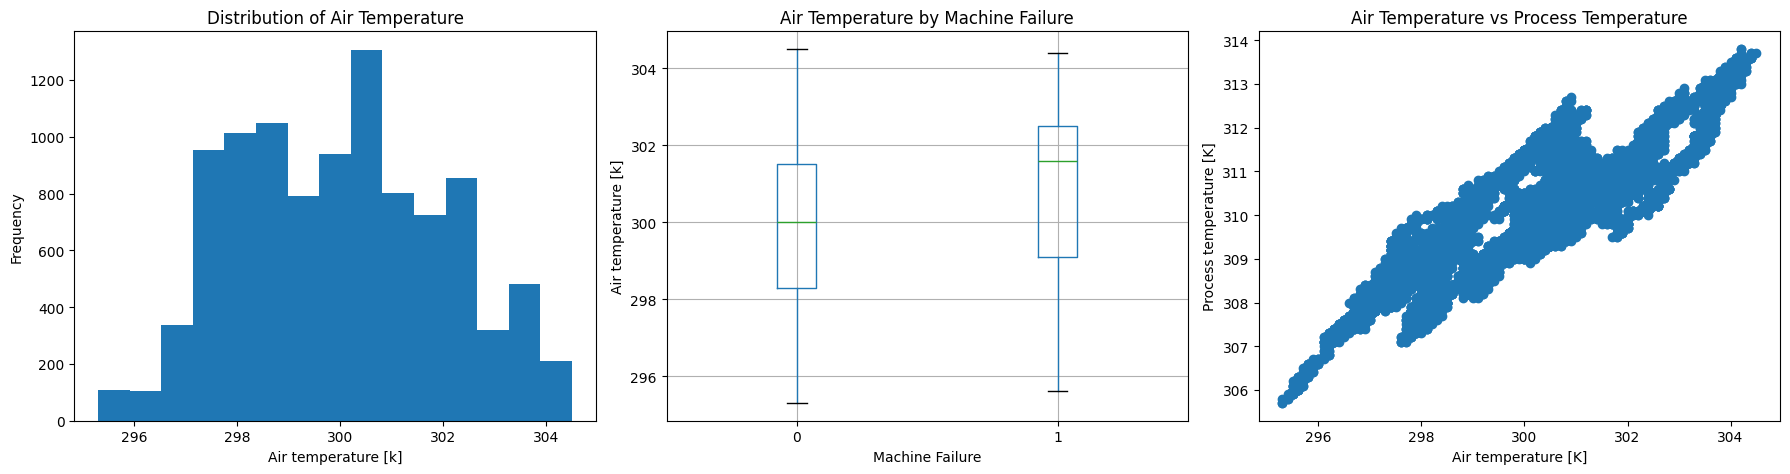

In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
# Histogram
axes[0].hist(df["Air temperature [K]"],bins=15)
axes[0].set_xlabel("Air temperature [k]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Air Temperature")

# Boxplot by machine failure
df.boxplot(
    column = "Air temperature [K]",
    by = 'Machine failure',
    ax = axes[1]
)
axes[1].set_title('Air Temperature by Machine Failure')
axes[1].set_xlabel("Machine Failure")
axes[1].set_ylabel("Air temperature [k]")

# Scatter plot
axes[2].scatter(
    df["Air temperature [K]"],
    df["Process temperature [K]"]
)
axes[2].set_xlabel('Air temperature [K]')
axes[2].set_ylabel('Process temperature [K]')
axes[2].set_title('Air Temperature vs Process Temperature')

plt.suptitle('')

plt.tight_layout()
plt.show()


1. We can notice from the middle subplot that Machine Failure tends to happen in higher temperature enviroment because it becomes harder for the machine to dessipate heat in high temperature enviroments leading to Heat Dissipation Failure
2. The relationship between the air temperature and process temperature strengthens the insight above

#### Process temprature

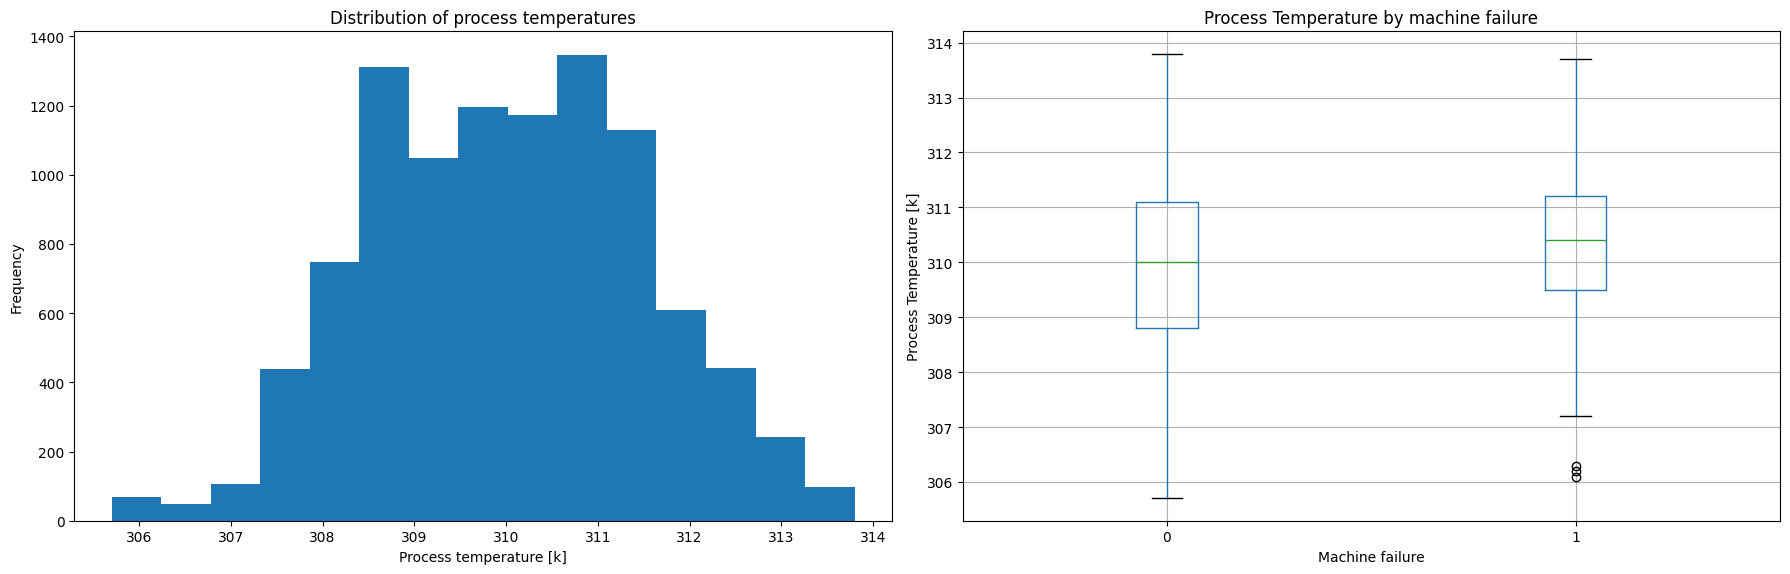

In [16]:
fig, axes = plt.subplots(1,2,figsize = (18,6))
axes[0].hist(df["Process temperature [K]"],bins = 15)
axes[0].set_xlabel("Process temperature [k]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of process temperatures")
df.boxplot(
    column ="Process temperature [K]",
    by="Machine failure",
    ax = axes[1]
)
axes[1].set_xlabel("Machine failure")
axes[1].set_ylabel("Process Temperature [k]")
axes[1].set_title("Process Temperature by machine failure")
plt.suptitle('')

plt.tight_layout()
plt.show()

Like the Air temperature, Machine failures tend to happen at a higher process temperature 

#### RPM

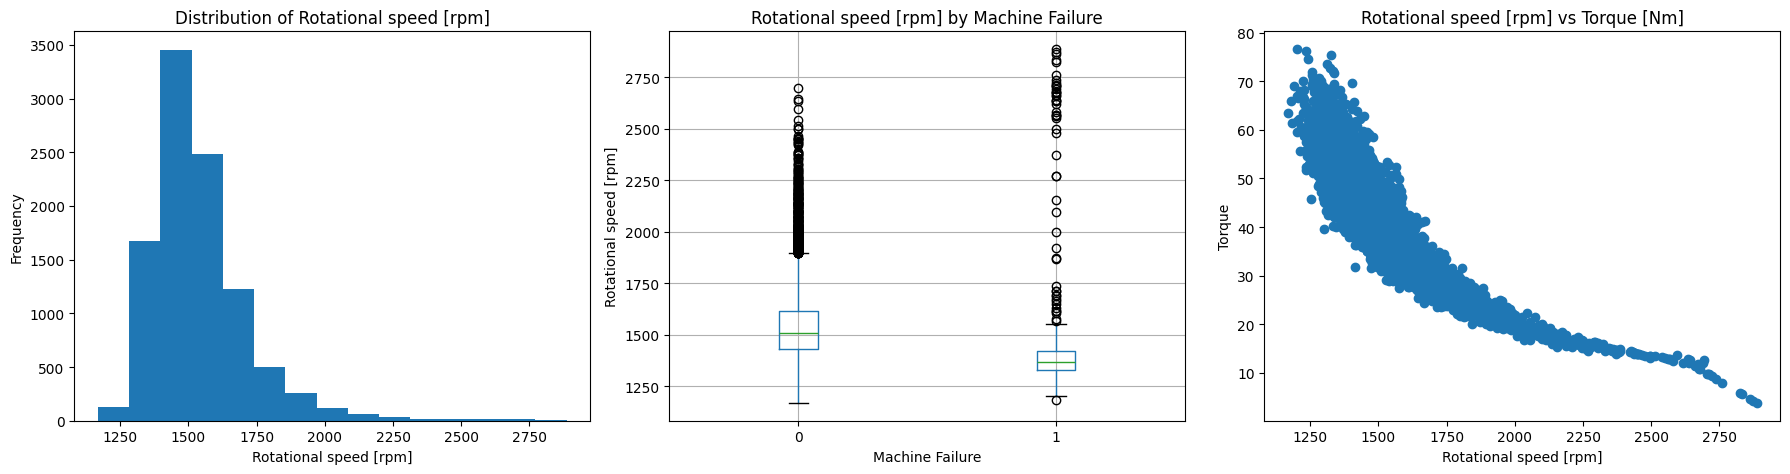

In [17]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
# Histogram
axes[0].hist(df["Rotational speed [rpm]"],bins=15)
axes[0].set_xlabel("Rotational speed [rpm]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Rotational speed [rpm]")

# Boxplot by machine failure
df.boxplot(
    column = "Rotational speed [rpm]",
    by = 'Machine failure',
    ax = axes[1]
)
axes[1].set_title('Rotational speed [rpm] by Machine Failure')
axes[1].set_xlabel("Machine Failure")
axes[1].set_ylabel("Rotational speed [rpm]")

# Scatter plot
axes[2].scatter(
    df["Rotational speed [rpm]"],
    df["Torque [Nm]"]
)
axes[2].set_xlabel('Rotational speed [rpm]')
axes[2].set_ylabel('Torque')
axes[2].set_title('Rotational speed [rpm] vs Torque [Nm]')

plt.suptitle('')

plt.tight_layout()
plt.show()


1. The subplot in the middle tells us that machine failure tends to happen at a low RPM, however because there are multiple outliers in the boxplot that has high RPM even at failure, we cannot generalize the idea of low RPM = Higher chance of machine failure.
2. The subplot on the right insights an inverse non-linear relationship between the RPM and the Torque. Which makes sense because for a given power range : Power = Torque * angular speed.
3. Another insight is that machine failures tends to happen at high mechanical resistance regions (High Torque,Low RPM) But the next Torque plots will confirm our insight 
4. One other possible insight is that machine failure tends to happen at high mechanical stress (When Power is maximum) so we must introduce a "Power" feature which is the product between "Torque (NM) * Rotational Speed (RPM) * (2*pi/60)

#### Torque

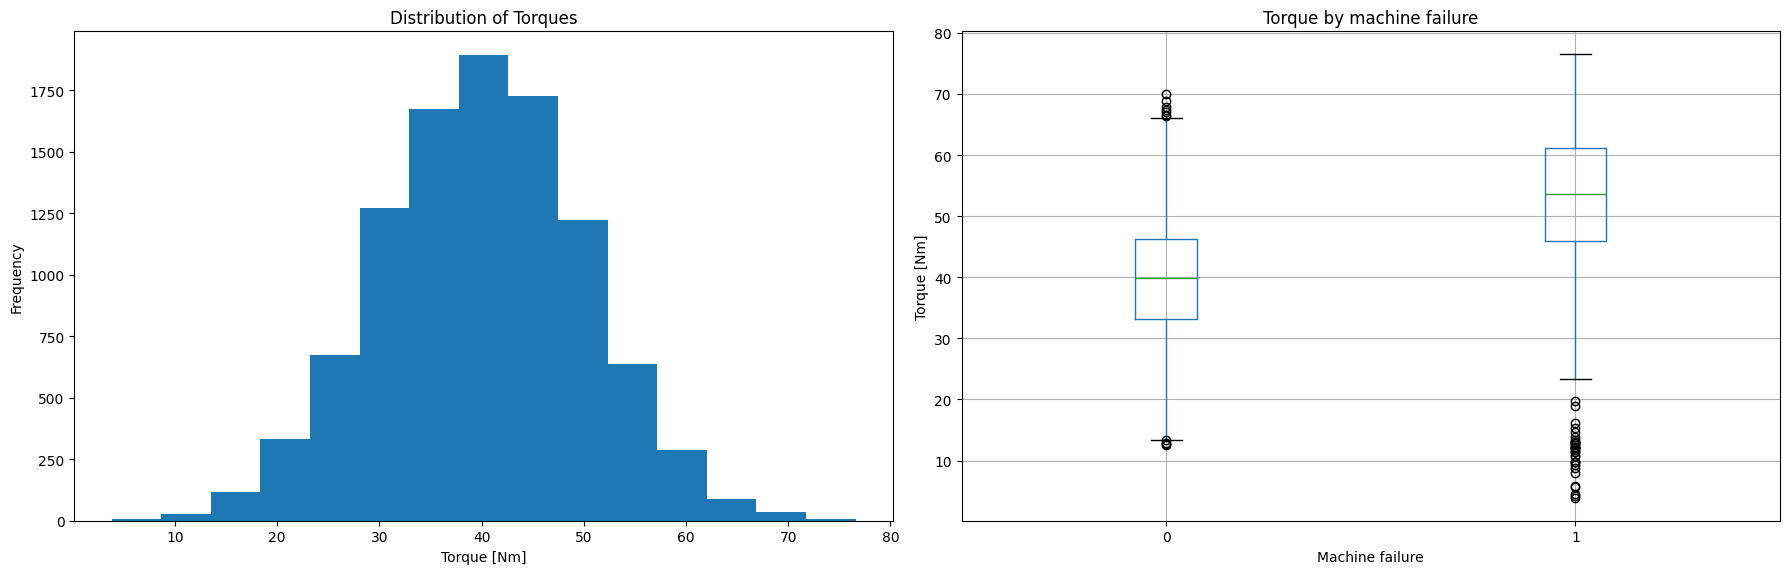

In [18]:
fig, axes = plt.subplots(1,2,figsize = (18,6))
axes[0].hist(df["Torque [Nm]"],bins = 15)
axes[0].set_xlabel("Torque [Nm]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Torques")
df.boxplot(
    column ="Torque [Nm]",
    by="Machine failure",
    ax = axes[1]
)
axes[1].set_xlabel("Machine failure")
axes[1].set_ylabel("Torque [Nm]")
axes[1].set_title("Torque by machine failure")
plt.suptitle('')

plt.tight_layout()
plt.show()

Like Speculated in the RPM analysis section the high torque-low rpm region gives a higher chance of failure.

#### Power

In [19]:
import numpy as np

df['Power [W]'] = (
    df['Torque [Nm]'] *
    df['Rotational speed [rpm]'] *
    2 * np.pi / 60
)

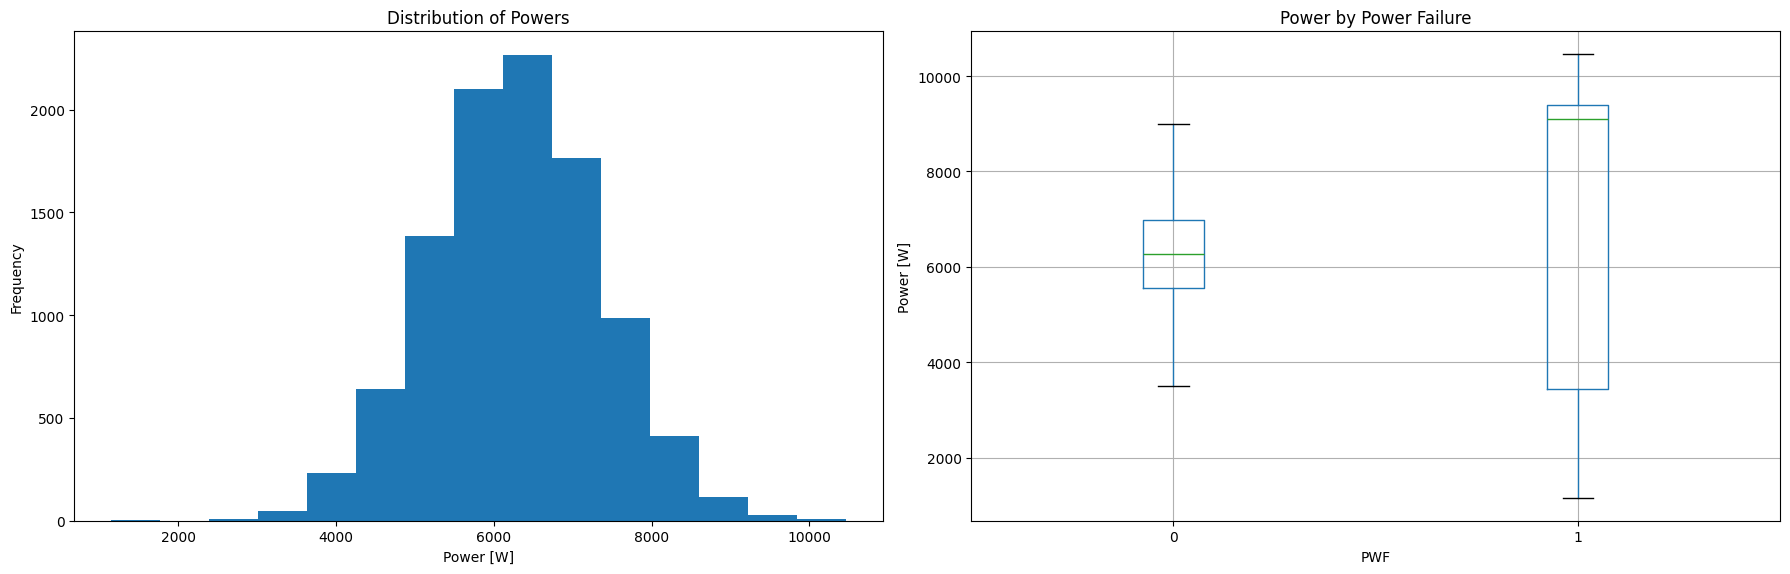

In [20]:
fig, axes = plt.subplots(1,2,figsize = (18,6))
axes[0].hist(df["Power [W]"],bins = 15)
axes[0].set_xlabel("Power [W]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Powers")
df.boxplot(
    column ="Power [W]",
    by="PWF",
    ax = axes[1]
)
axes[1].set_xlabel("PWF")
axes[1].set_ylabel("Power [W]")
axes[1].set_title("Power by Power Failure")
plt.suptitle('')

plt.tight_layout()
plt.show()

As expected the right subplot shows a higher probability of machine failure for machines operating at a higher power.

#### Tool Wear

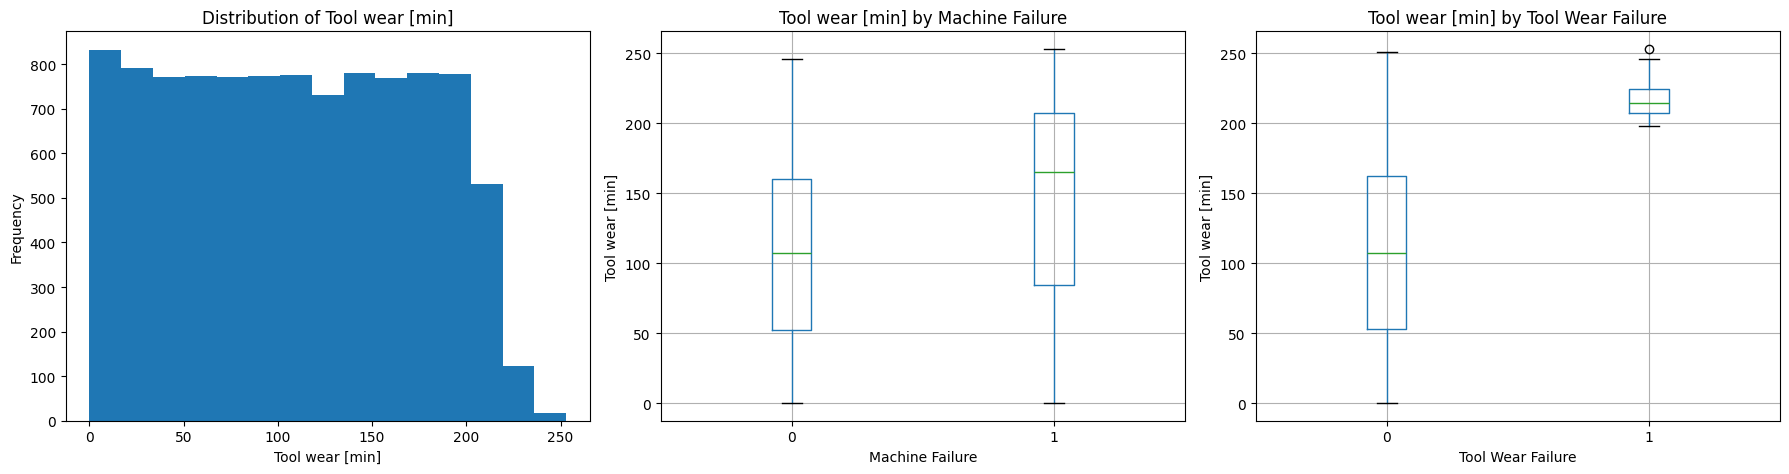

In [21]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
# Histogram
axes[0].hist(df["Tool wear [min]"],bins=15)
axes[0].set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Tool wear [min]")

# Boxplot by machine failure
df.boxplot(
    column = "Tool wear [min]",
    by = 'Machine failure',
    ax = axes[1]
)
axes[1].set_title('Tool wear [min] by Machine Failure')
axes[1].set_xlabel("Machine Failure")
axes[1].set_ylabel("Tool wear [min]")

# Boxplot by Tool wear failure
df.boxplot(
    column = "Tool wear [min]",
    by = 'TWF',
    ax = axes[2]
)
axes[2].set_title('Tool wear [min] by Tool Wear Failure')
axes[2].set_xlabel("Tool Wear Failure")
axes[2].set_ylabel("Tool wear [min]")

plt.suptitle('')

plt.tight_layout()
plt.show()


In [22]:
df['Temp_diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [23]:
df['Torque_Wear'] = df['Torque [Nm]'] * df['Tool wear [min]']

## Initial Univariate and Target Insights

- The target variable is highly imbalanced, with normal operation cases being much more frequent than failure cases.Therefore, accuracy alone will not be a reliable evaluation metric. Precision, recall, F1-score, ROC-AUC, and PR-AUC should be considered during modeling.
- The numerical features show different distributions and ranges, which may require scaling for linear models.
- Some variables contain many outliers, especially rotational speed and torque.
- In predictive maintenance, outliers should not be removed blindly because extreme sensor values may represent real failure behavior.

#### Correlation analysis

In [24]:
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]
corr_matrix = df[numeric_cols].corr()
corr_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


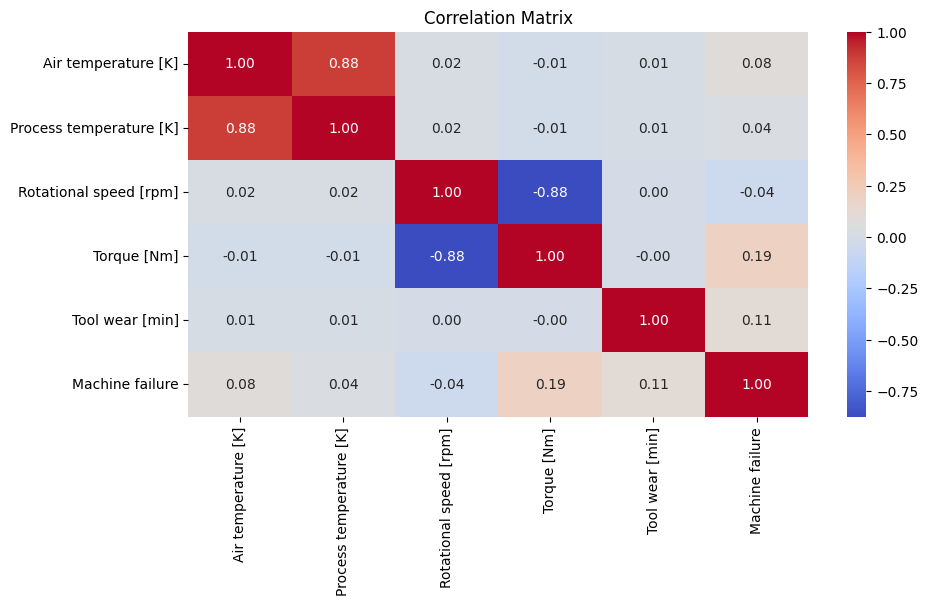

In [25]:
import seaborn as sns

plt.figure(figsize =(10,5))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

- Air temperature and process temperature are expected to be strongly positively correlated.
- Rotational speed and torque are expected to be strongly negatively correlated.
- Machine failure may not show very strong linear correlation with individual features because failure depends on nonlinear interactions. However, it looks like the feature affecting machine failure the most are Torque and Tool wear.

In [26]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Power [W]',
]

failure_type_means = {}

for col in failure_cols:
    failure_type_means[col] = df[df[col] == 1][features].mean()

failure_type_means_df = pd.DataFrame(failure_type_means)

failure_type_means_df

,TWF,HDF,PWF,OSF,RNF
Air temperature [K],300.297826,302.560870,300.075789,300.044898,300.815789
Process temperature [K],310.165217,310.788696,309.954737,310.073469,310.763158
Rotational speed [rpm],1566.173913,1337.260870,1763.968421,1350.326531,1485.000000
Torque [Nm],37.836957,53.166957,48.514737,58.370408,43.673684
Tool wear [min],216.369565,107.191304,101.884211,207.693878,124.473684
Power [W],6019.326127,7433.167575,7251.822098,8230.217595,6685.701039


Comparing feature averages between normal and failed machines helps identify which variables shift during failure conditions. However, mean values alone are not sufficient because several failure mechanisms are nonlinear and interaction-based.

### Outlier analysis

In [27]:
def iqr_outlier_summary(data, columns):
    summary = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        
        summary.append({
            'Feature': col,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': len(outliers),
            'Outlier Percentage': len(outliers) / len(data) * 100
        })
    return pd.DataFrame(summary)
outlier_summary = iqr_outlier_summary(df,features)

In [28]:
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_data = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(col)
    print(outlier_data['Machine failure'].value_counts(normalize=True) * 100)
    print('-' * 50)

Air temperature [K]
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Process temperature [K]
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Rotational speed [rpm]
Machine failure
0    91.626794
1     8.373206
Name: proportion, dtype: float64
--------------------------------------------------
Torque [Nm]
Machine failure
1    89.855072
0    10.144928
Name: proportion, dtype: float64
--------------------------------------------------
Tool wear [min]
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Power [W]
Machine failure
1    100.0
Name: proportion, dtype: float64
--------------------------------------------------


Outliers were analyzed using the IQR method. However, they were not removed automatically because extreme values in predictive maintenance may represent abnormal machine behavior or actual failure conditions rather than data errors.

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\605064059.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  torque_failure_rate = df.groupby('Torque_bin')['Machine failure'].mean() * 100


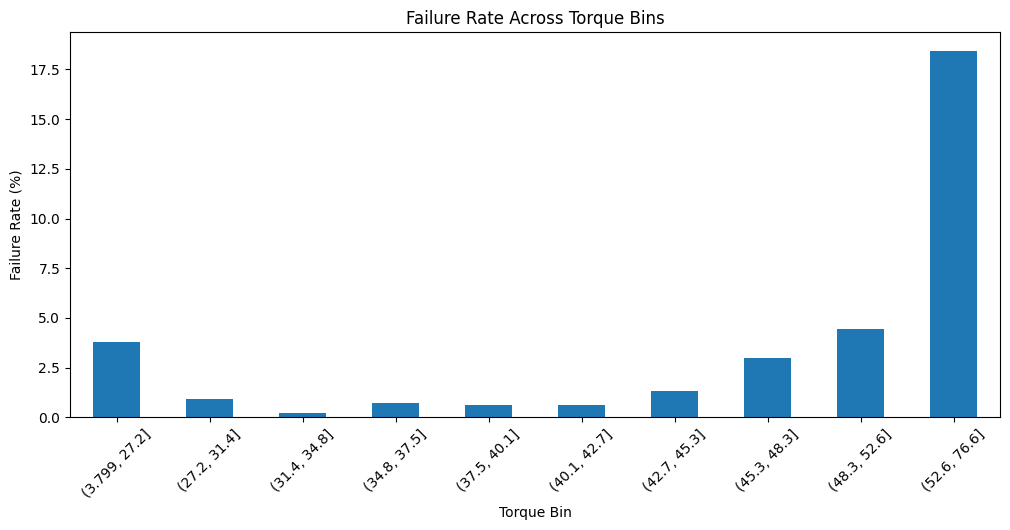

In [29]:
df['Torque_bin'] = pd.qcut(df['Torque [Nm]'], q=10, duplicates='drop')

torque_failure_rate = df.groupby('Torque_bin')['Machine failure'].mean() * 100

torque_failure_rate.plot(kind='bar', figsize=(12, 5))

plt.xlabel('Torque Bin')
plt.ylabel('Failure Rate (%)')
plt.title('Failure Rate Across Torque Bins')
plt.xticks(rotation=45)
plt.show()

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


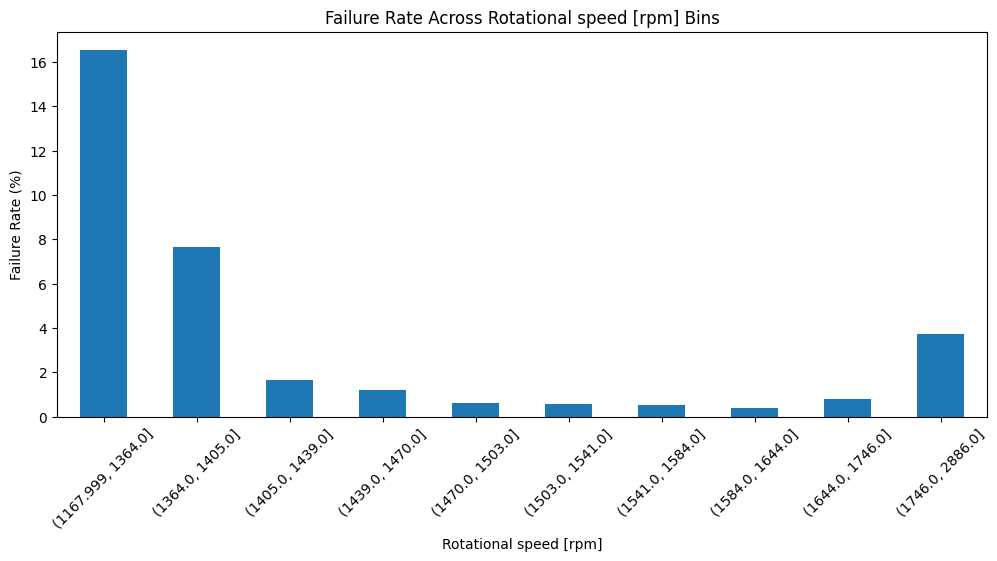

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


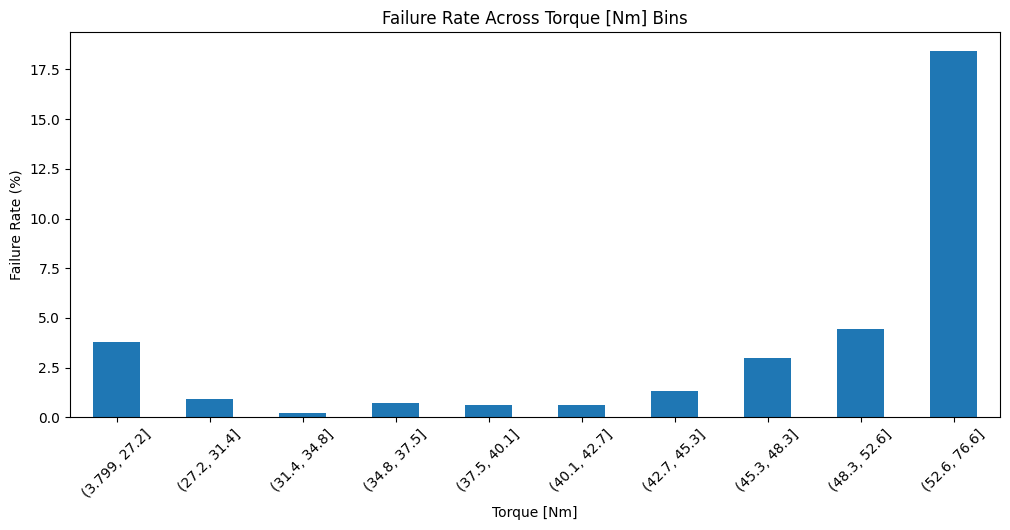

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


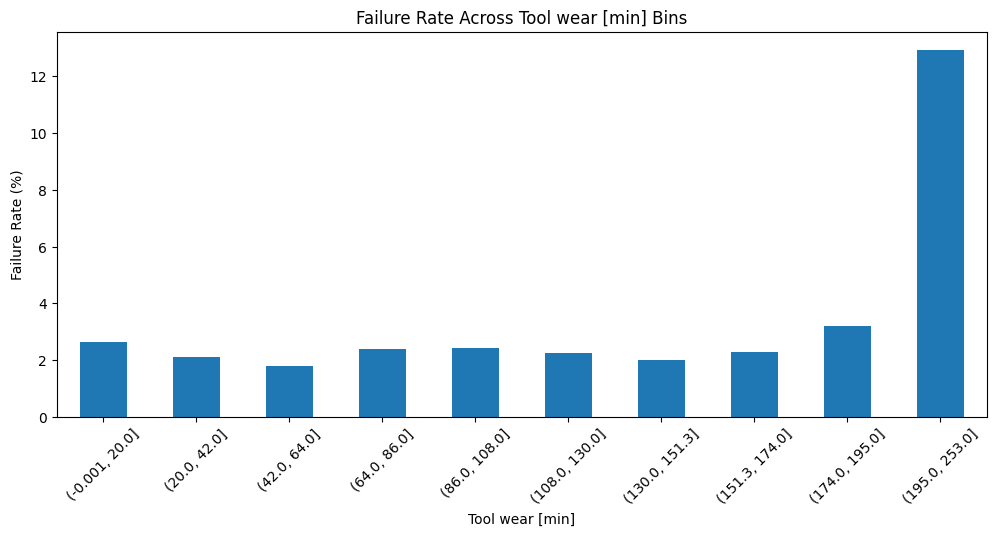

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


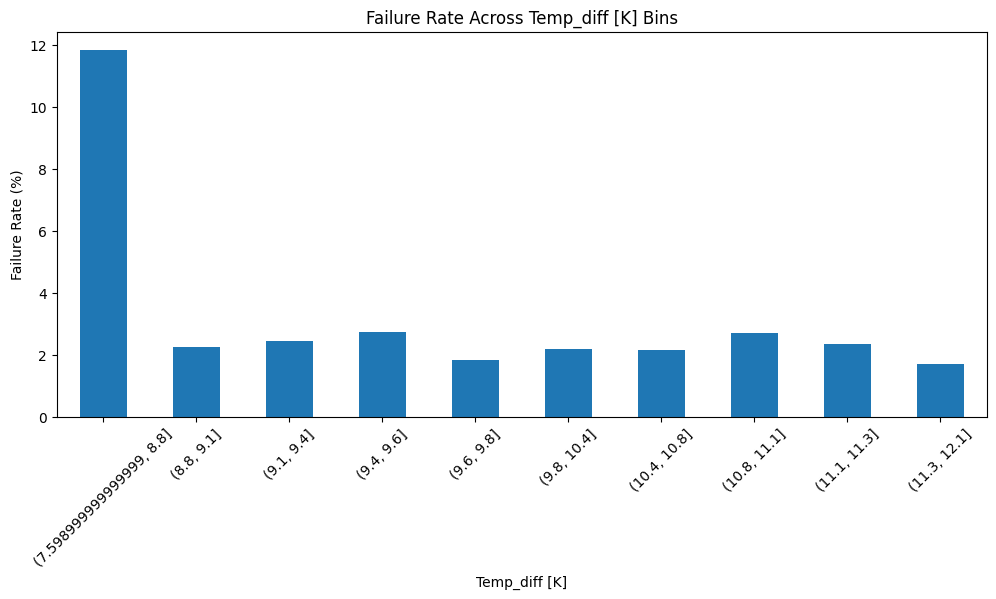

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


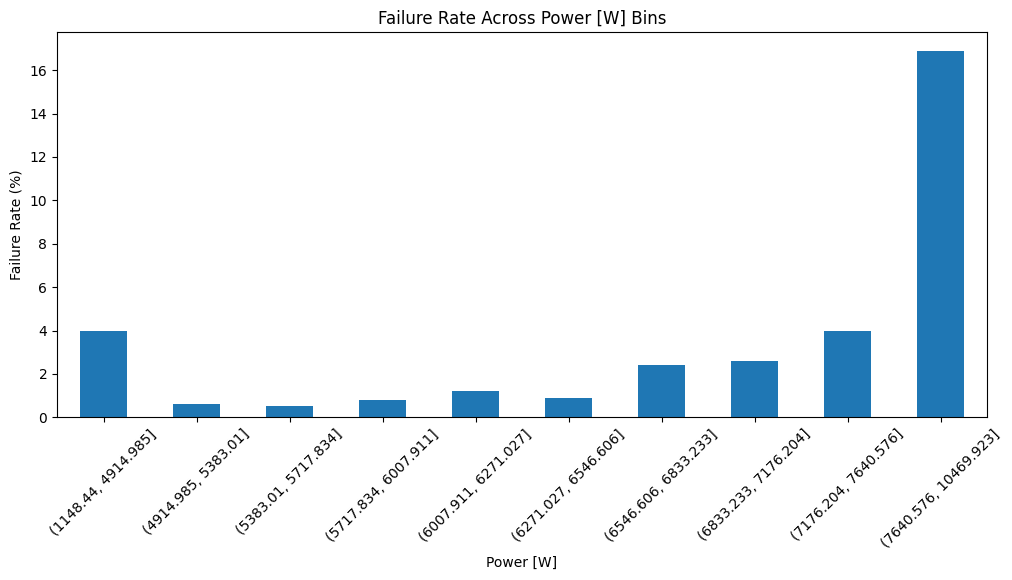

C:\Users\yhamz\AppData\Local\Temp\ipykernel_13160\3925390221.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100


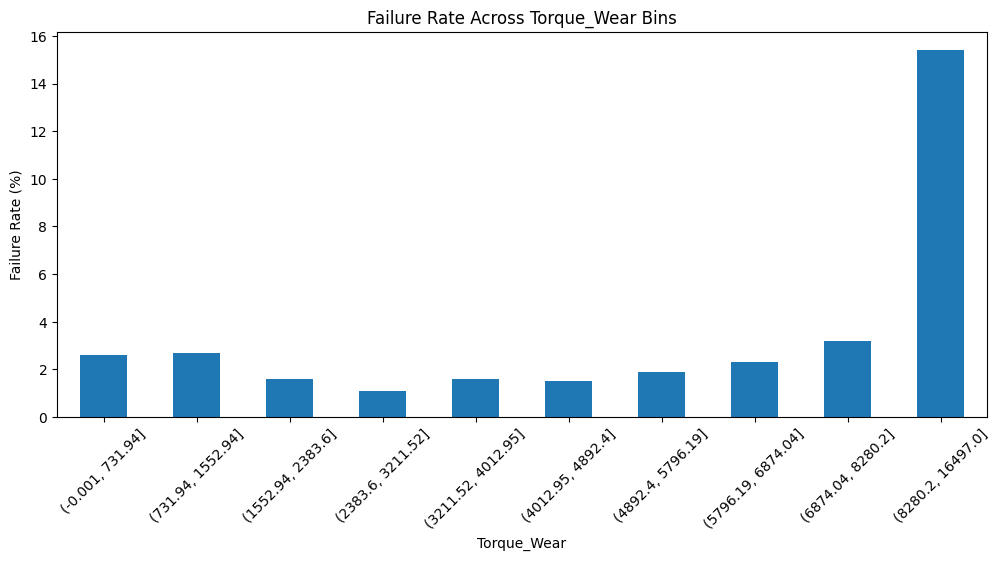

In [30]:
important_features = [
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temp_diff [K]',
    'Power [W]',
    'Torque_Wear'
]
for col in important_features:
    bin_col = col + '_bin'
    df[bin_col] = pd.qcut(df[col], q=10, duplicates = 'drop')
    
    failure_rate = df.groupby(bin_col)['Machine failure'].mean() *100
    plt.figure(figsize=(12,5))
    failure_rate.plot(kind = 'bar')
    plt.xlabel(col)
    plt.ylabel('Failure Rate (%)')
    plt.title(f'Failure Rate Across {col} Bins')
    plt.xticks(rotation=45)
    plt.show()

Binned failure-rate analysis helps reveal nonlinear relationships between sensor values and machine failure. This is especially important because failure probability may increase only at extreme operating ranges rather than changing linearly across the full feature range.

## Final EDA Summary

1. The dataset contains a highly imbalanced binary target, where machine failures are rare compared to normal operation.
2. Failure-type labels are useful for EDA but should not be used as model features because they leak target information.
3. A small label inconsistency was observed, mainly involving RNF, which may behave as random label noise.
4. Air temperature and process temperature are strongly related, suggesting that ambient conditions influence process temperature.
5. Rotational speed and torque show a strong inverse relationship, indicating a mechanical power-related operating pattern.
6. Engineered features such as temperature difference, mechanical power, and torque-wear interaction provide more domain-relevant information than raw sensor values alone.
7. Outliers were detected but not removed automatically because extreme sensor values may represent meaningful failure behavior.
8. Failure mechanisms appear to be interaction-based and nonlinear, suggesting that tree-based models such as Random Forest, XGBoost, or LightGBM may perform well.
9. Due to class imbalance, model evaluation should focus on recall, precision, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone.
